In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")

In [2]:
data = load_penguins()
data.dropna(inplace=True)

In [3]:
data.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
 7   year               333 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 23.4 KB


In [8]:
# Proper data conversion

data[['sex', 'species', 'island']] = data[['sex', 'species', 'island']].astype('category')
data.info()


<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            333 non-null    category
 1   island             333 non-null    category
 2   bill_length_mm     333 non-null    float64 
 3   bill_depth_mm      333 non-null    float64 
 4   flipper_length_mm  333 non-null    float64 
 5   body_mass_g        333 non-null    float64 
 6   sex                333 non-null    category
 7   year               333 non-null    int64   
dtypes: category(3), float64(4), int64(1)
memory usage: 16.6 KB


# Visual examination

## Pairplot

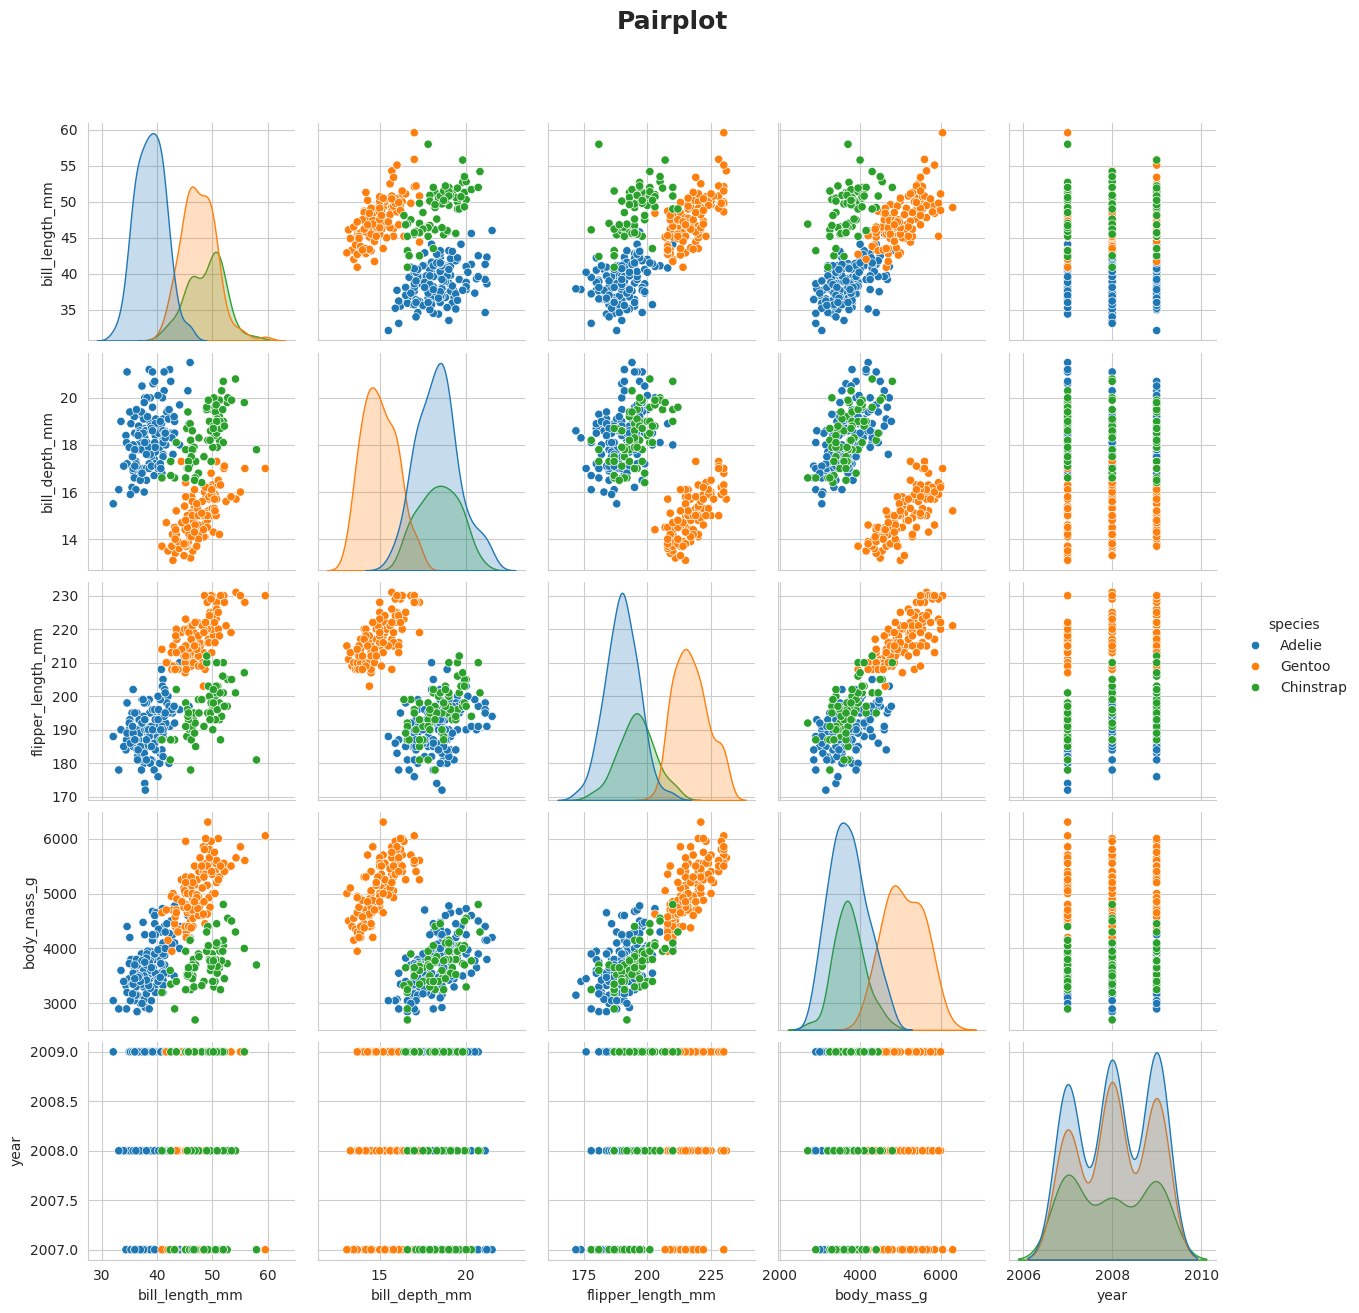

In [4]:
g = sns.pairplot(data, hue='species')
g.figure.suptitle('Pairplot', fontsize=18, fontweight='bold', y=1.05)
g.tight_layout()
plt.show()

## Correlations

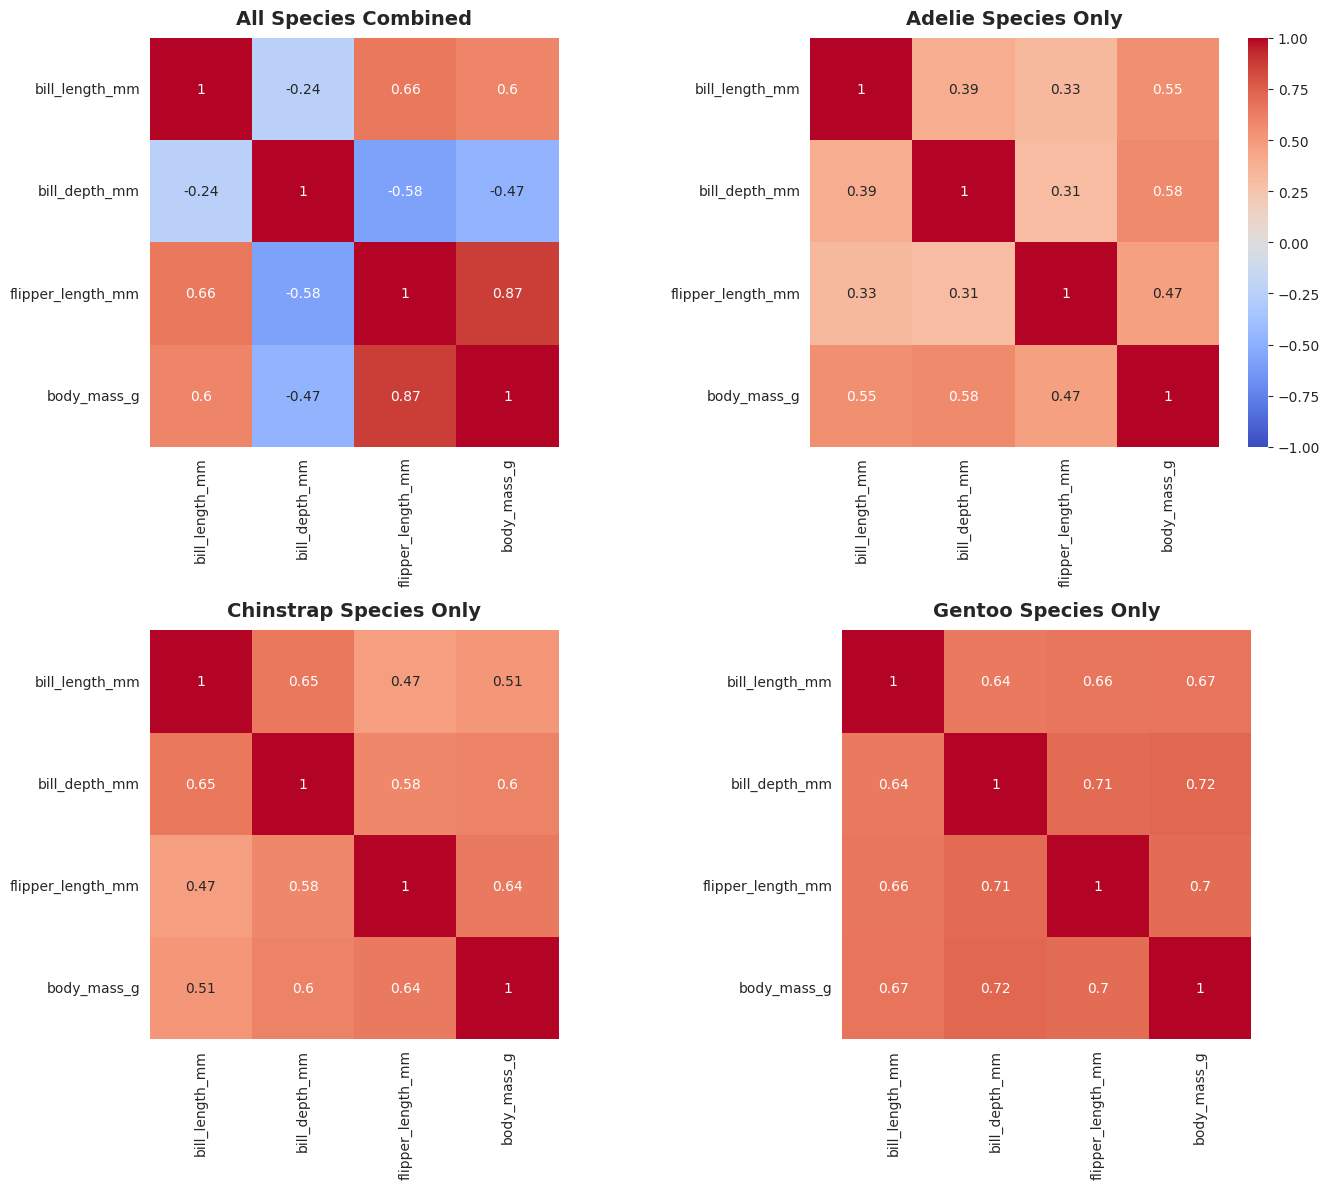

In [5]:
# 1. Load data and filter for numeric columns
df = sns.load_dataset("penguins")
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# 2. Set up the 2x2 figure grid (Standard figure-based layout)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten to make indexing 0, 1, 2, 3 easier

# Define our 4 plotting scenarios
scenarios = [
    {"title": "All Species Combined", "data": df},
    {"title": "Adelie Species Only", "data": df[df["species"] == "Adelie"]},
    {"title": "Chinstrap Species Only", "data": df[df["species"] == "Chinstrap"]},
    {"title": "Gentoo Species Only", "data": df[df["species"] == "Gentoo"]},
]

# 3. Loop through scenarios and plot heatmaps
for i, scenario in enumerate(scenarios):
    # Compute correlation matrix for the numeric features
    corr_matrix = scenario["data"][features].corr()

    # Plot using axes-level sns.heatmap on the specific grid spot
    sns.heatmap(
        corr_matrix,
        ax=axes[i],
        annot=True,  # Shows the correlation numbers
        cmap="coolwarm",  # Good divergence palette for correlations
        vmin=-1,
        vmax=1,  # Forces same color scale for comparison
        square=True,  # Keeps the subplots perfectly square
        cbar=True if i == 1 else False,  # Keeps layout clean by showing only 1 colorbar
    )

    axes[i].set_title(scenario["title"], fontsize=14, fontweight="bold", pad=10)

# 4. Final layout polish
plt.tight_layout()
plt.show()


The correlation results change significantly when analyzed with all the three species combined versus when analyzed each species independently. This is called the Simpson's paradox and requires the inclusion of the categorical variable defining the groups. In this case, the categorical variable is the species.

## Linear Plot

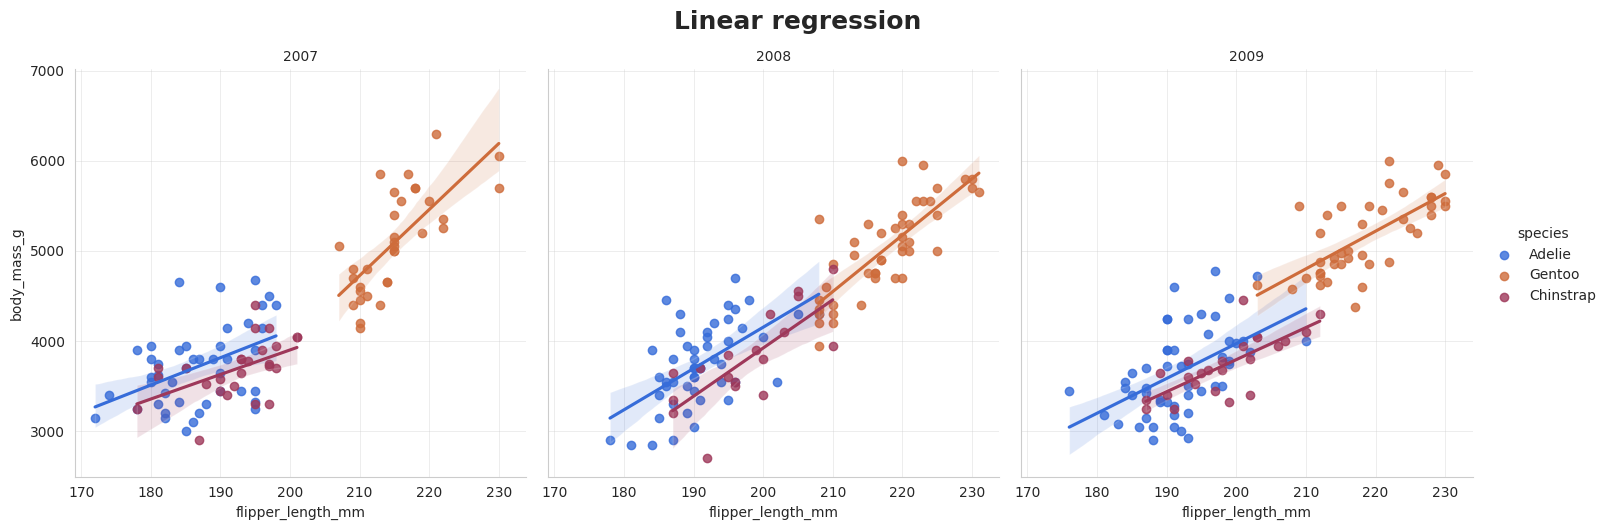

In [8]:
g = sns.lmplot(data, x='flipper_length_mm', y='body_mass_g', hue='species', col='year', col_wrap=3)
g.set_titles('{col_name}')
g.fig.suptitle('Linear regression', fontsize=18, fontweight='bold', y=1.05)
plt.show()

# Linear Regression

## Inferential workflow

### 1. Training and testing split

In [16]:
X = data.drop('body_mass_g', axis=1)
y = data['body_mass_g']
train, test =train_test_split(data, test_size=0.2, random_state=42)

In [17]:
print(f'Training set: {train.shape} and testing set {test.shape} ')

Training set: (266, 8) and testing set (67, 8) 


### 2. EDA

Year variable: numeric or categorical?

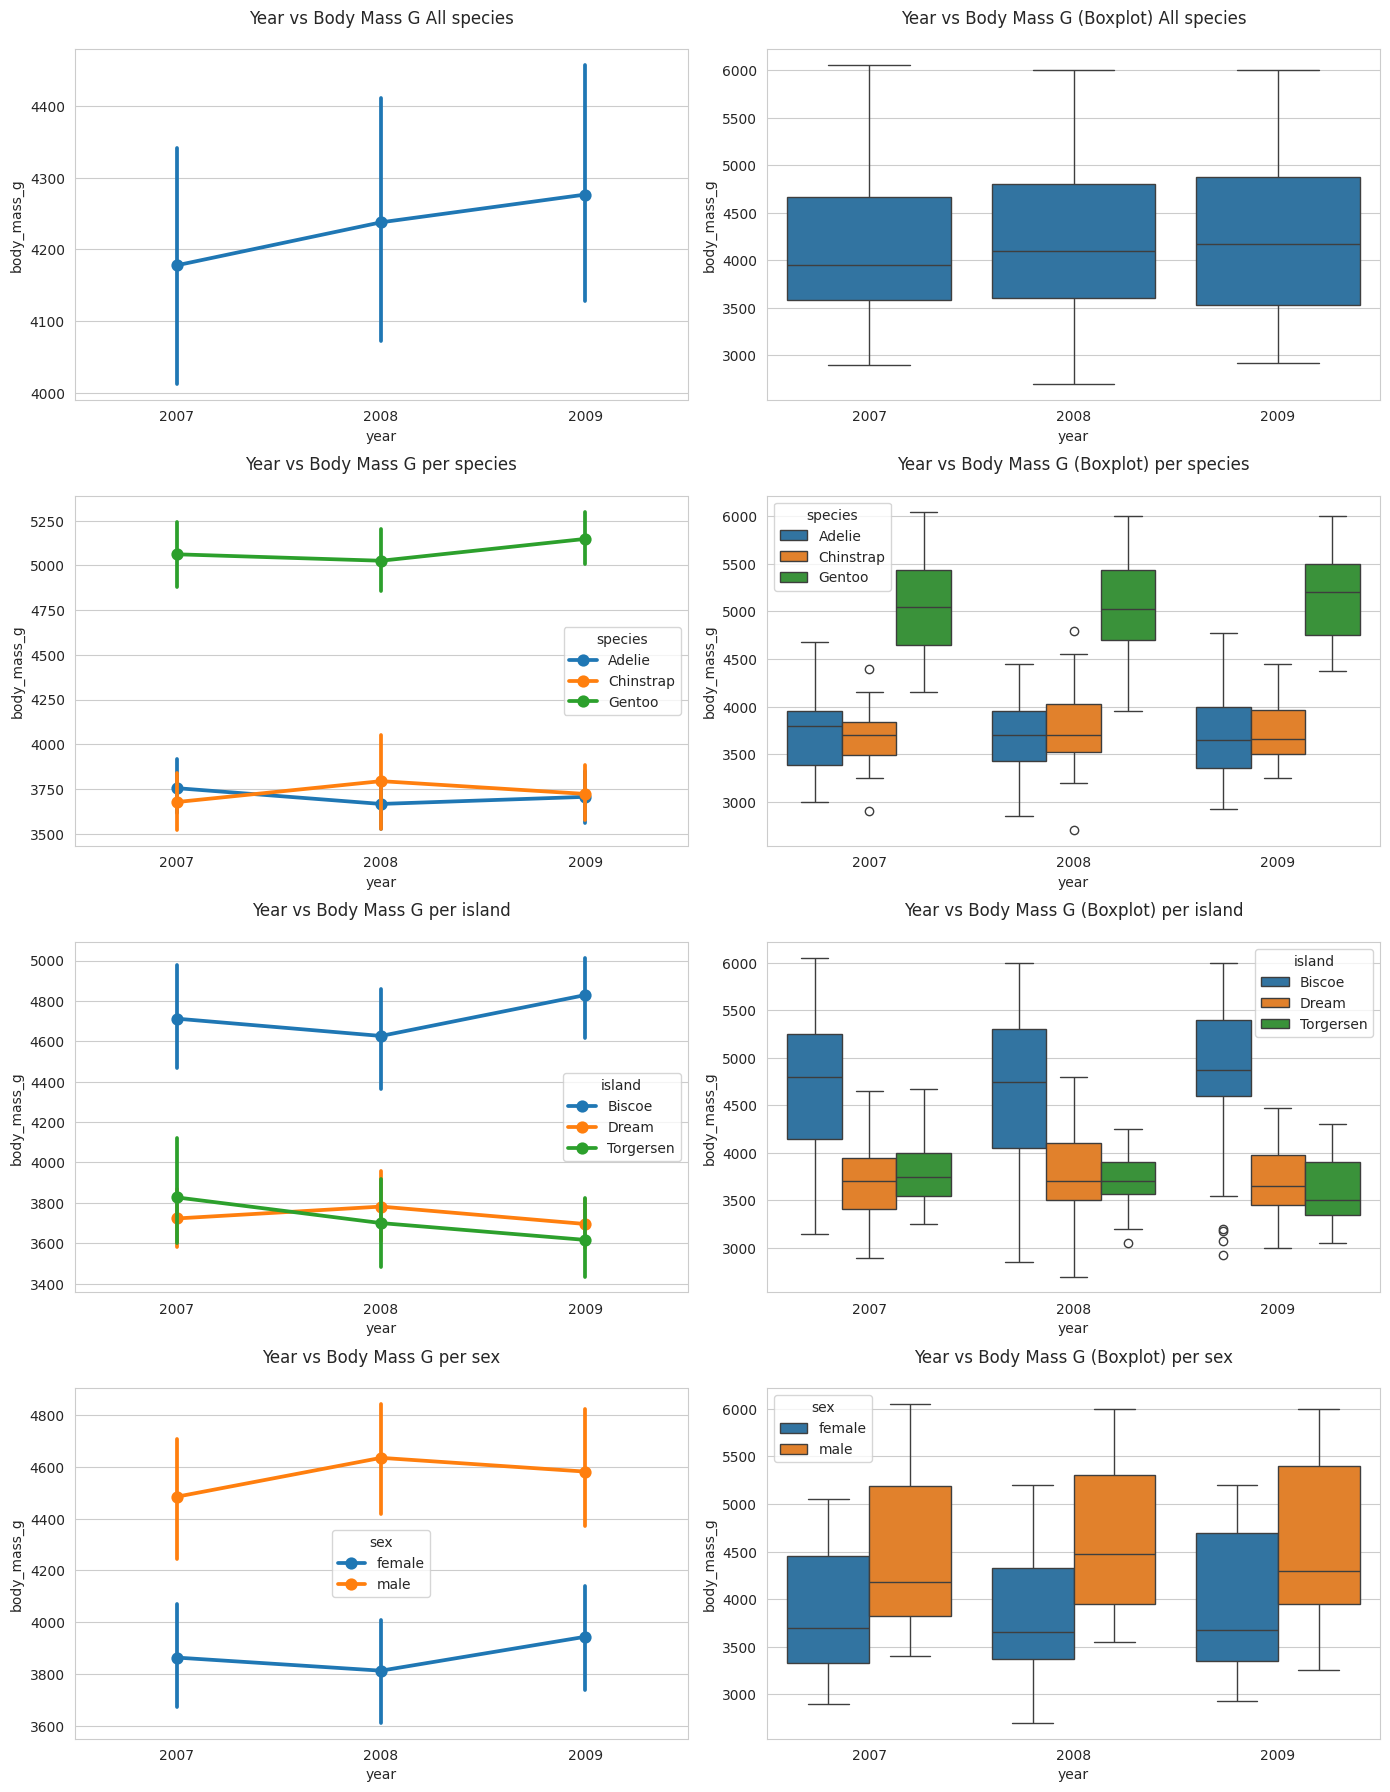

In [35]:
figure, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()
sns.pointplot(data=train, x='year', y='body_mass_g', ax=axes[0])
axes[0].set_title('Year vs Body Mass G All species', y=1.05)
sns.boxplot(data=train, x='year', y='body_mass_g', ax=axes[1])
axes[1].set_title('Year vs Body Mass G (Boxplot) All species', y=1.05)

sns.pointplot(data=train, x='year', y='body_mass_g', ax=axes[2], hue='species')
axes[2].set_title('Year vs Body Mass G per species', y=1.05)
sns.boxplot(data=train, x='year', y='body_mass_g', ax=axes[3], hue='species')
axes[3].set_title('Year vs Body Mass G (Boxplot) per species', y=1.05)

sns.pointplot(data=train, x='year', y='body_mass_g', ax=axes[4], hue='island')
axes[4].set_title('Year vs Body Mass G per island', y=1.05)
sns.boxplot(data=train, x='year', y='body_mass_g', ax=axes[5], hue='island')
axes[5].set_title('Year vs Body Mass G (Boxplot) per island', y=1.05)

sns.pointplot(data=train, x='year', y='body_mass_g', ax=axes[6], hue='sex')
axes[6].set_title('Year vs Body Mass G per sex', y=1.05)
sns.boxplot(data=train, x='year', y='body_mass_g', ax=axes[7], hue='sex')
axes[7].set_title('Year vs Body Mass G (Boxplot) per sex', y=1.05)

plt.tight_layout()
plt.show()

There is a tren through the years so 'year' will remain as a numerical variable

Correlations from Species perspective

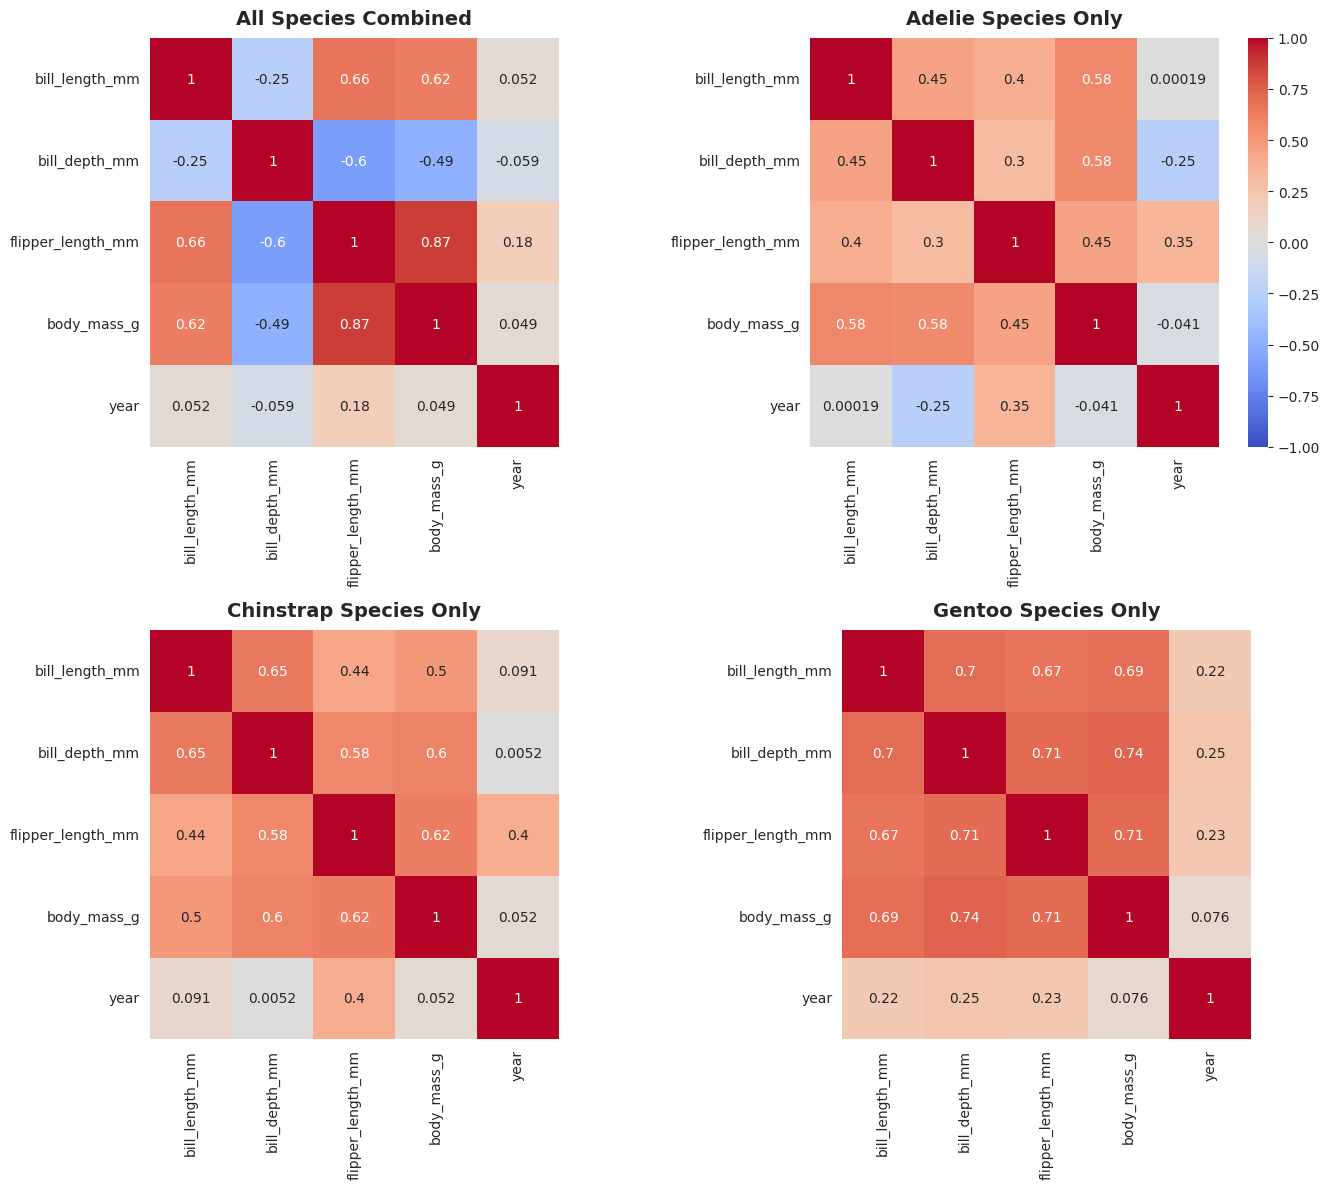

In [34]:
# 1. Load data and filter for numeric columns
df = train
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", 'year']

# 2. Set up the 2x2 figure grid (Standard figure-based layout)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten to make indexing 0, 1, 2, 3 easier

# Define our 4 plotting scenarios
scenarios = [
    {"title": "All Species Combined", "data": df},
    {"title": "Adelie Species Only", "data": df[df["species"] == "Adelie"]},
    {"title": "Chinstrap Species Only", "data": df[df["species"] == "Chinstrap"]},
    {"title": "Gentoo Species Only", "data": df[df["species"] == "Gentoo"]},
]

# 3. Loop through scenarios and plot heatmaps
for i, scenario in enumerate(scenarios):
    # Compute correlation matrix for the numeric features
    corr_matrix = scenario["data"][features].corr()

    # Plot using axes-level sns.heatmap on the specific grid spot
    sns.heatmap(
        corr_matrix,
        ax=axes[i],
        annot=True,  # Shows the correlation numbers
        cmap="coolwarm",  # Good divergence palette for correlations
        vmin=-1,
        vmax=1,  # Forces same color scale for comparison
        square=True,  # Keeps the subplots perfectly square
        cbar=True if i == 1 else False,  # Keeps layout clean by showing only 1 colorbar
    )

    axes[i].set_title(scenario["title"], fontsize=14, fontweight="bold", pad=10)

# 4. Final layout polish
plt.tight_layout()
plt.show()


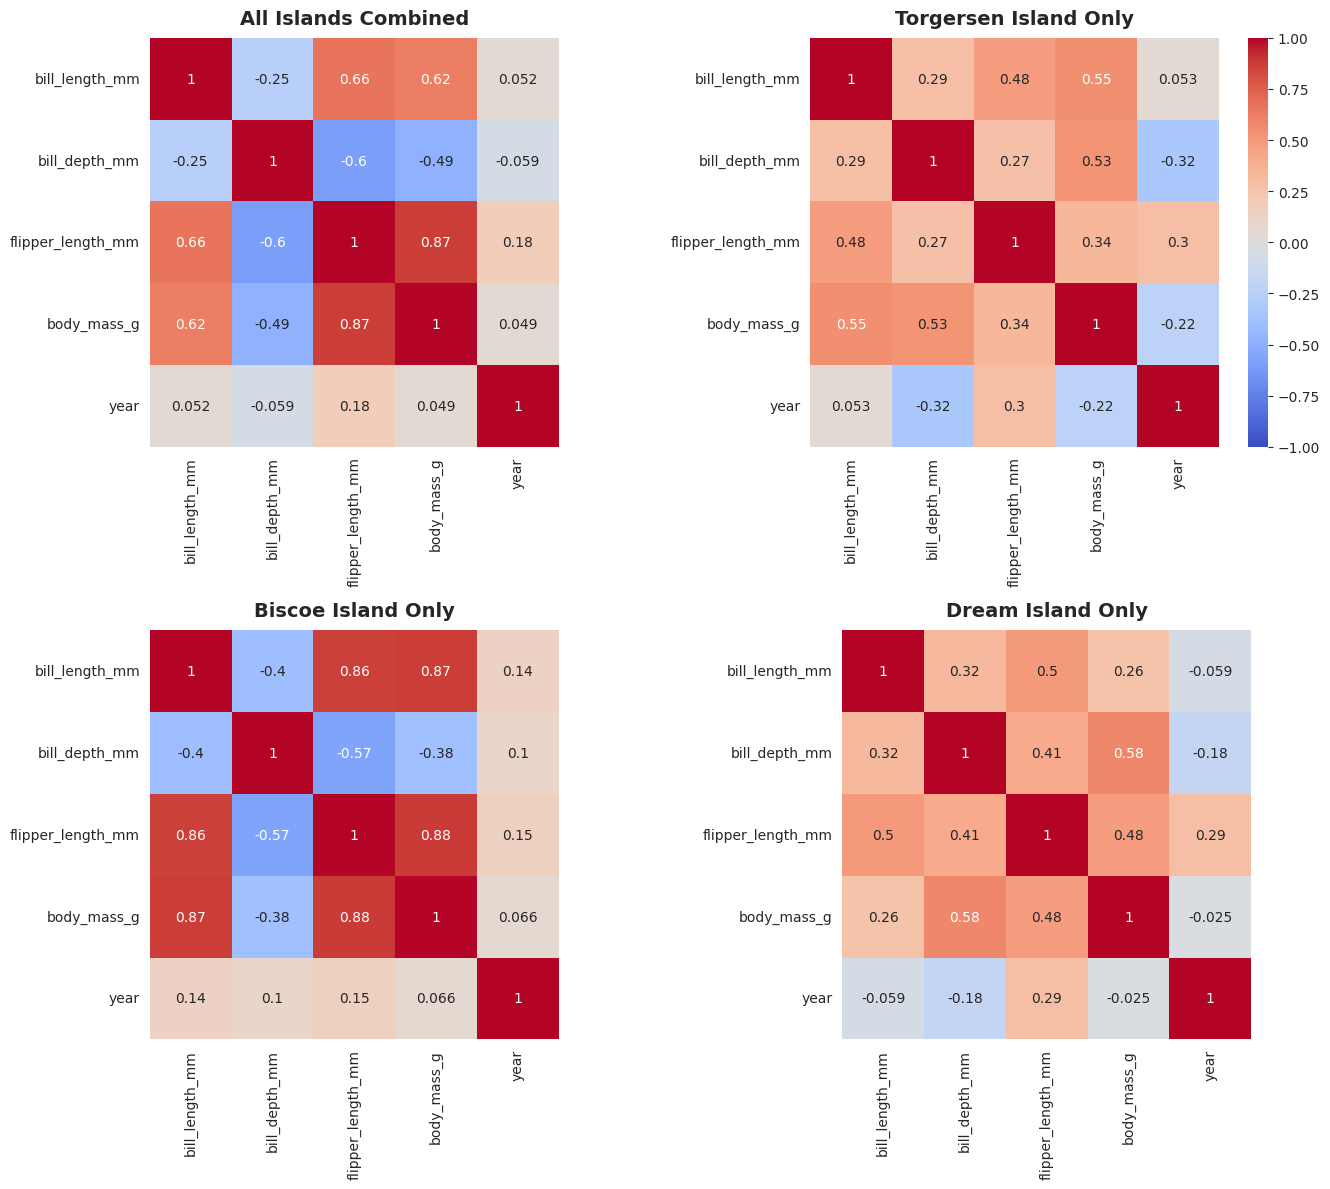

In [37]:
# 1. Load data and filter for numeric columns
df = train
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", 'year']

# 2. Set up the 2x2 figure grid (Standard figure-based layout)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten to make indexing 0, 1, 2, 3 easier

# Define our 4 plotting scenarios
scenarios = [
    {"title": "All Islands Combined", "data": df},
    {"title": "Torgersen Island Only", "data": df[df["island"] == "Torgersen"]},
    {"title": "Biscoe Island Only", "data": df[df["island"] == "Biscoe"]},
    {"title": "Dream Island Only", "data": df[df["island"] == "Dream"]}
]

# 3. Loop through scenarios and plot heatmaps
for i, scenario in enumerate(scenarios):
    # Compute correlation matrix for the numeric features
    corr_matrix = scenario["data"][features].corr()

    # Plot using axes-level sns.heatmap on the specific grid spot
    sns.heatmap(
        corr_matrix,
        ax=axes[i],
        annot=True,  # Shows the correlation numbers
        cmap="coolwarm",  # Good divergence palette for correlations
        vmin=-1,
        vmax=1,  # Forces same color scale for comparison
        square=True,  # Keeps the subplots perfectly square
        cbar=True if i == 1 else False,  # Keeps layout clean by showing only 1 colorbar
    )

    axes[i].set_title(scenario["title"], fontsize=14, fontweight="bold", pad=10)

# 4. Final layout polish
plt.tight_layout()
plt.show()


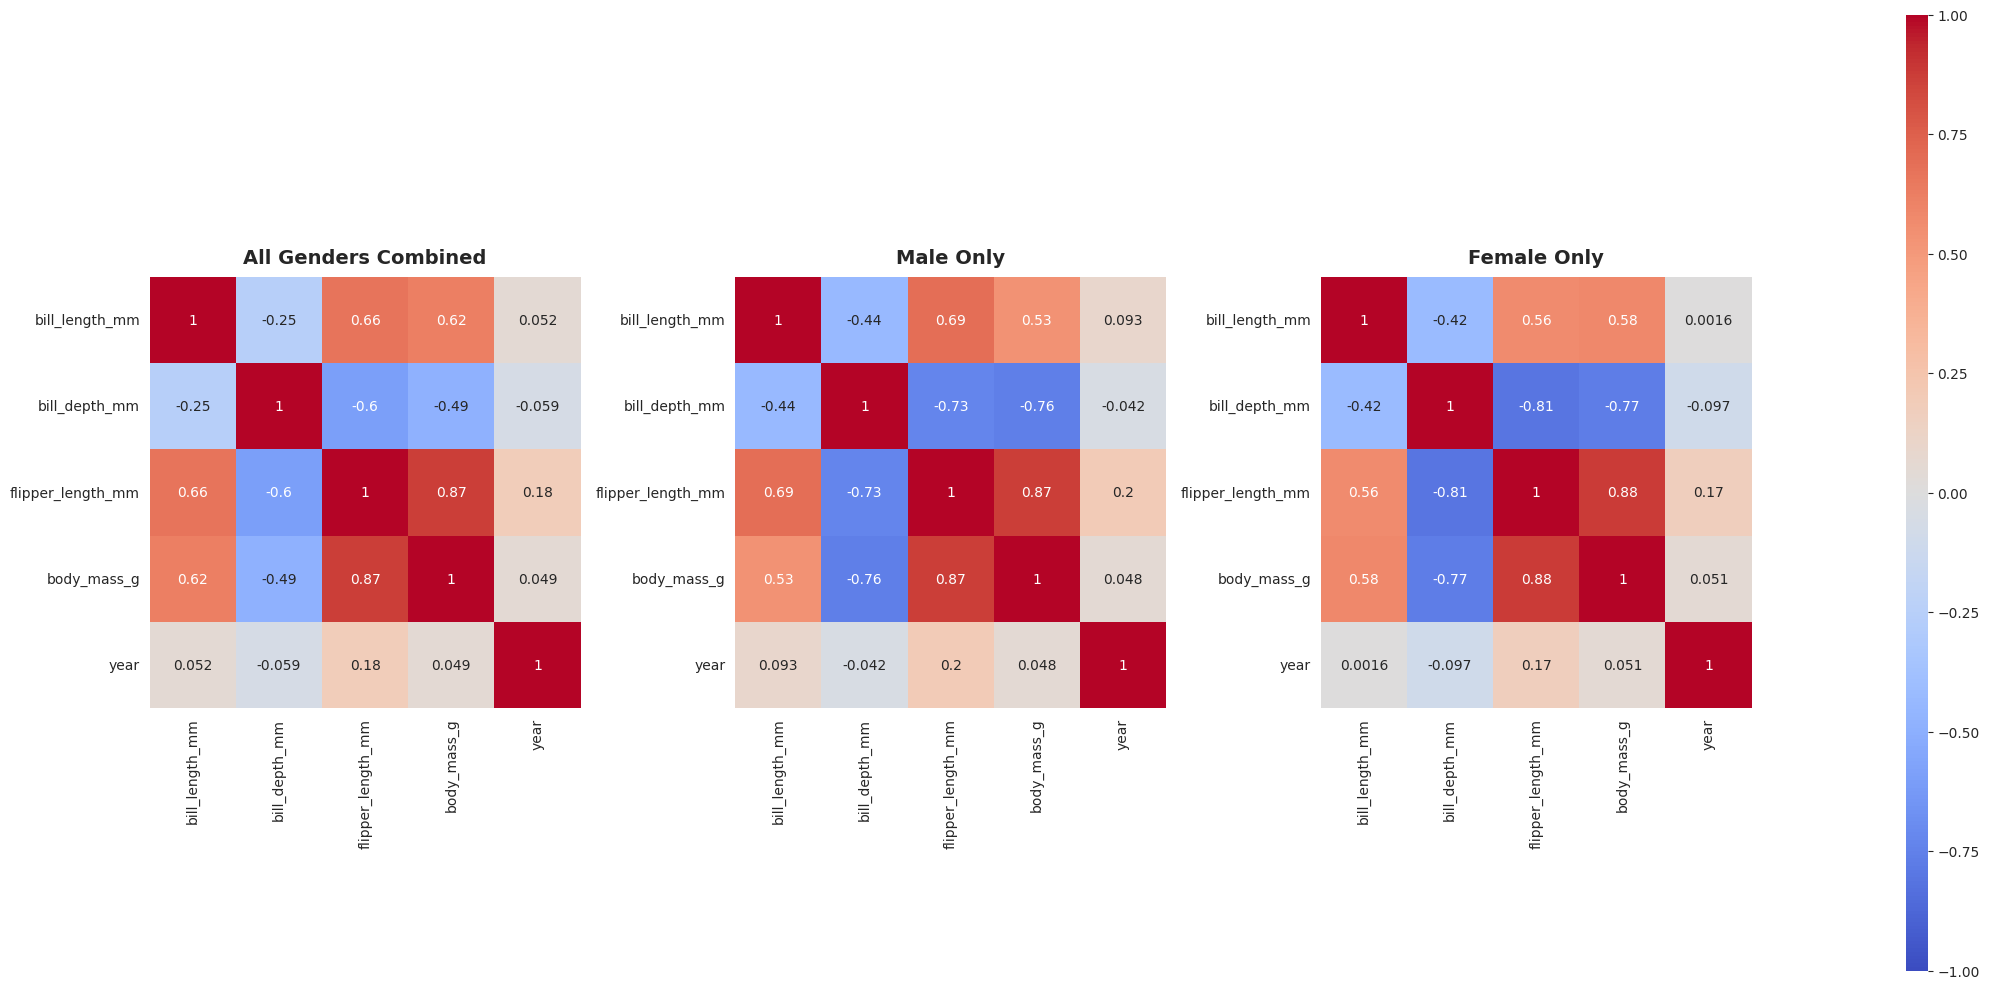

In [50]:
# 1. Load data and filter for numeric columns
df = train
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", 'year']

# 2. Set up the figure grid with an extra column for the colorbar
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 10), gridspec_kw={'width_ratios': [1, 1, 1, 0.05]})
cbar_ax = axes[-1]  # The last axis will be used for the colorbar

# Define our 3 plotting scenarios
scenarios = [
    {"title": "All Genders Combined", "data": df},
    {"title": "Male Only", "data": df[df["sex"] == "male"]},
    {"title": "Female Only", "data": df[df["sex"] == "female"]}
]

# 3. Loop through scenarios and plot heatmaps
for i, scenario in enumerate(scenarios):
    # Compute correlation matrix for the numeric features
    corr_matrix = scenario["data"][features].corr()

    # Plot using axes-level sns.heatmap on the specific grid spot
    sns.heatmap(
        corr_matrix,
        ax=axes[i],
        annot=True,  # Shows the correlation numbers
        cmap="coolwarm",  # Good divergence palette for correlations
        vmin=-1,
        vmax=1,  # Forces same color scale for comparison
        square=True,  # Keeps the subplots perfectly square
        cbar=True if i == 2 else False,  # Show colorbar only on the last heatmap
        cbar_ax=cbar_ax if i == 2 else None,  # Assign the colorbar to the dedicated axis
    )

    axes[i].set_title(scenario["title"], fontsize=14, fontweight="bold", pad=10)

# 4. Final layout polish
plt.tight_layout()
plt.show()


# DRAFT

In [43]:
data.sex.unique()

['male', 'female']
Categories (2, str): ['female', 'male']

In [1]:
model1 = smf.ols('body_mass_g ~ flipper_length_mm', data).fit()
print(model1.summary())

NameError: name 'smf' is not defined

In [55]:
model2 = smf.ols('body_mass_g ~ flipper_length_mm + species', data).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     405.3
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.14e-110
Time:                        23:02:41   Log-Likelihood:                -2442.6
No. Observations:                 333   AIC:                             4893.
Df Residuals:                     329   BIC:                             4908.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -4013.1789 

In [57]:
model3 = smf.ols('body_mass_g ~ flipper_length_mm + species + year', data).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     321.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.98e-112
Time:                        23:04:17   Log-Likelihood:                -2435.0
No. Observations:                 333   AIC:                             4880.
Df Residuals:                     328   BIC:                             4899.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.985e+05 

In [58]:
model4 = smf.ols('body_mass_g ~ flipper_length_mm + species + year + bill_length_mm + bill_depth_mm + island', data).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     235.2
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          5.15e-130
Time:                        23:07:05   Log-Likelihood:                -2380.8
No. Observations:                 333   AIC:                             4780.
Df Residuals:                     324   BIC:                             4814.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.091e+05 

In [59]:
model5 = smf.ols('body_mass_g ~ flipper_length_mm + species + year + bill_length_mm + bill_depth_mm', data).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     313.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.77e-132
Time:                        23:08:19   Log-Likelihood:                -2381.9
No. Observations:                 333   AIC:                             4778.
Df Residuals:                     326   BIC:                             4804.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.054e+05 

In [65]:
model6 = smf.ols('body_mass_g ~ flipper_length_mm + species + bill_length_mm + bill_depth_mm', data).fit()
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     369.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.22e-132
Time:                        23:12:48   Log-Likelihood:                -2384.8
No. Observations:                 333   AIC:                             4782.
Df Residuals:                     327   BIC:                             4805.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -4282.0802 

In [78]:
np.sqrt(model5.mse_resid)

np.float64(312.46204364419003)